In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [2]:
file_path = "./Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
df = pd.read_csv(file_path)

In [3]:
print("Sample data:")
df.head()

Sample data:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
df.columns = df.columns.str.strip()

In [6]:
sample_space_size = len(df)
num_attacks = df[df['Label'] != 'BENIGN'].shape[0]
num_benign = df[df['Label'] == 'BENIGN'].shape[0]
print(f"Sample size: {sample_space_size}")
print(f"num_attacks:  {num_attacks} and Benign {num_benign}")
#print(num_attacks + num_benign)

Sample size: 225745
num_attacks:  128027 and Benign 97718


In [10]:
p_attack = num_attacks / sample_space_size

p_benign = num_benign / sample_space_size

print(f"p(attack) = {p_attack: .4f}")
print(f"p(attack) = {p_attack: .4f}")

p(attack) =  0.5671
p(attack) =  0.5671


In [38]:
#conditional Probability P(Attack | Destination Port = 80)
port80_traffic = df[df['Destination Port'] == 80]
p_attack_given_port80 = (port80_traffic['Label'] != 'BENIGN').mean()
print(f"P(Attack | Destination Port = 80): {p_attack_given_port80:.4f}")


P(Attack | Destination Port = 80): 0.9348


In [21]:
#conditional Probability P(Destination Port = 80 | Attack)
attacks = df[df['Label'] != 'BENIGN']
p_port_80_given_attack = (attacks['Destination Port'] == 80).mean()
print(f"P(Destination Port = 80 | Attack): {p_port_80_given_attack:.4f}")

P(Destination Port = 80 | Attack): 1.0000


P(B∣A)=P(B)P(A∣B)|P(A)​
P(Port 80∣Attack)= P(Attack ∩ Port 80)​| P(Attack)
P(Attack ∩ Port 80)=count of (attack AND port 80 rows)​| total rows in dataset

# Choose 'Flow Duration'>1,000,000 μs and formulate a Bayes theorem-based question. i.e. compute P(Attack∣Long Duration) 
# Applying Bayes’ Theorem to Network Traffic

To determine the likelihood of an attack based on flow duration, we define our events and apply the theorem as follows:

## 1. Define the Events
*   **Event $A$:** Attack
*   **Event $L$:** Flow Duration > 1,000,000

### Goal:
Find **$P(A|L)$**  
*(The probability that a flow is an attack, given it has a long duration.)*

---

## 2. Bayes’ Theorem Formula
To find the reverse condition, we use the following equation:

$$P(A|L) = \frac{P(L|A)P(A)}{P(L)}$$

### Where:
*   **$P(L|A)$**: The probability that an attack has a long duration.
*   **$P(A)$**: The prior probability of an attack occurring (base rate).
*   **$P(L)$**: The total probability of any flow having a long duration.

In [12]:
#Define event
long_flow = df['Flow Duration'] > 1_000_000
attack = df['Label'] != 'BENIGN'

#probabilities
p_attack = attack.mean()
p_long = long_flow.mean()

#p(Long Flow | Attack)
p_long_given_attack = (df[attack]['Flow Duration'] > 1_000_000).mean()

#Bayes theorem: P(Attack | Long Flow)
p_attack_given_long = (p_long_given_attack * p_attack) / p_long

print(f"P(Long Duration)={p_long}")
print(f"P(Long Duration | Attack)= {p_long_given_attack}")
print(f"P(Attack | Flow Duration > 1,000,000) = {p_attack_given_long:.5f}")

P(Long Duration)=0.5570045848191544
P(Long Duration | Attack)= 0.6613995485327314
P(Attack | Flow Duration > 1,000,000) = 0.67342


If you observe a long-duration flow, there is a ~67% chance that it is an attack — higher than the base rate of 56.7%.

In [5]:
from scipy import stats

attack_prob = (df['Label'] != 'BENIGN').mean()
print(f"Estimated attack probability (p): {attack_prob:.4f}")


n_trials = 10
k_success = 7

print(stats.binom)
binom_prob = stats.binom.pmf(k_success, n_trials, attack_prob) # note: to get the documentation u may need to print help(stats.binom); the parent class
print(f"P(getting exactly 7 attacks out of 10) = {binom_prob:.4f}")

Estimated attack probability (p): 0.5671
P(getting exactly 7 attacks out of 10) = 0.1837


#### ✅ Task for students:
- Choose a numerical feature 'Total Fwd Packets' and fit a normal distribution using MLE (Maximum Likelihood Estimation) using scipy stats model.
- Plot the histogram and overlay the fitted normal PDF. Does it match well?
- Does the normal curve align well with the histogram?
- Compare visually – are the tails and center well captured?
- Why might the fit not be perfect for real-world network data?
- Explain the shape of the data to your AI assistant and ask it to find a more suited distribution that can be used for the modeling.

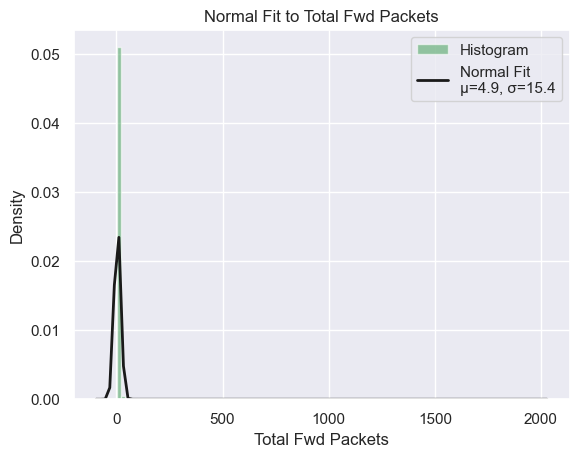

In [27]:
feature = "Total Fwd Packets"

data = pd.to_numeric(df[feature], errors = 'coerce')
data = data[np.isfinite(data)]

mu, std = stats.norm.fit(data)

plt.hist(data, bins=100, density=True, alpha=0.6, color='g', label='Histogram')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f"Normal Fit\nμ={mu:.1f}, σ={std:.1f}")
plt.title(f"Normal Fit to {feature}")
plt.xlabel(feature)
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

- Choose a numerical feature 'Flow Duration' and plot its distribution.
- Comment on the shape (normal, skewed, multimodal?)
- Compute the skewness and the kurtosis.

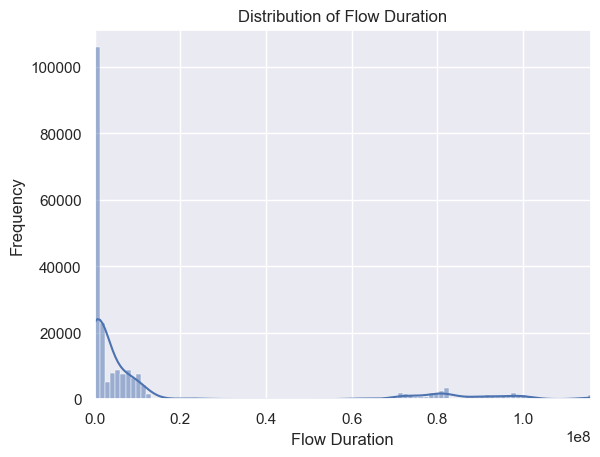

In [34]:
feature = 'Flow Duration'
sns.histplot(df[feature], bins=100, kde=True)
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Frequency")
plt.xlim(0, df[feature].quantile(0.99))
plt.show()

IQR

In [35]:
Q1 =df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)

IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR 
outliers = df[(df[feature] < lower_bound)| (df[feature] >  upper_bound)]

print(f"Total outliers in {feature}: {len(outliers)}")
print("outliers by label:")
print(outliers['Label'].value_counts())

Total outliers in Flow Duration: 37465
outliers by label:
Label
DDoS      21915
BENIGN    15550
Name: count, dtype: int64


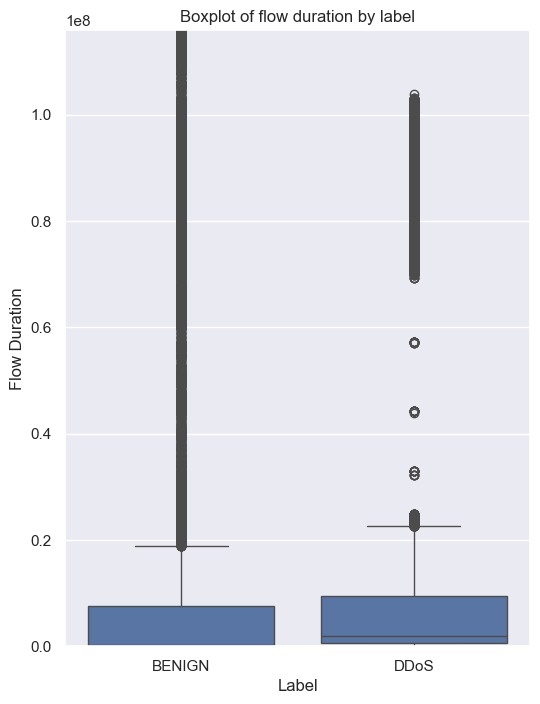

In [37]:
plt.figure(figsize=(6,8))
sns.boxplot(x = 'Label', y=feature, data=df, showfliers=True)
plt.title("Boxplot of flow duration by label")
plt.ylim(0, df[feature].quantile(0.99))
plt.show()

- In the following code, we sample different sample sizes and compute mean/std. 

- Do you expect the mean and the std. to change for each sample size? why do you think this is happening?

- What happens if you increase sample size?

In [ ]:
sample_sizes = []